# Single energy model: prediction quality, coefficients and neighborhoods

Load saved conditional mean-curvature models without fitting. Each model predicts deviations from an organoid's **measured mean**, optionally expressed in units of its **measured SD**. Models never receive measured node curvatures; the measured summaries enter only target construction and physical reconstruction. This is a conditional allocation task, not fate-only prediction of an unknown organoid shape.

Settings and model selection appear immediately below the imports. Validation MSE is averaged over cells **within each organoid**, then over organoids within each fold, and finally over folds. Overall MSE covers ordinary validation; the combined spherical-like/no-detected-crypt category also includes held-out spherical organoids. These are repeated across fold models, not independent new cohorts. Unqualified boundary cells remain in overall MSE and are omitted from regional panels. Fold SEM describes variation among these fitted models and is not a full uncertainty interval.

Inspect one model configuration at one accommodation across its saved folds. Coefficients describe local preferred curvature before accommodation and output centering. The arbitrary common center offset is not an absolute native-cell curvature. Artificial graphs then isolate the response to replacing one background cell, while keeping every node at degree six.

For the current γ=0.5 comparison, select `presence_no_self_r1` or `secretory_r1` in the settings. Each has a separate output directory containing figures, numerical tables and an executed copy of this notebook; the active notebook displays the no-self variant.

In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from scipy.sparse import csr_matrix, diags, eye
from scipy.sparse.linalg import factorized
from scipy.sparse.csgraph import shortest_path, dijkstra
PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p/'src/models/gnn.py').is_file())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0,str(PROJECT_ROOT))
from src.artifacts.bundle import load_bundle
from src.data.target_transforms import center_graph_values
from src.training.coupled_fit import graph_samples
from src.analysis.metrics.conditional import conditional_region_scores
from src.data.synthetic import triangular_lattice_edges
from src.data.neighborhood_counts import fate_identities


## Settings
Choose the completed run, normalization and model selection. All plotted quantities are reconstructed from its saved checkpoints and prediction archives.

In [ ]:
# Saved models and target definition
TRAINING_RUN = 'training_results/shape_conditioned_energy_training/no_self_secretory_gamma05_20261005_144506'  # Completed training folder; exact models and folds are restored.
TARGET_MODES = ['standardized']  # Mean subtraction or mean+SD standardization.
VARIANTS = ['secretory_r1']  # Exactly one: 'presence_no_self_r1' or 'secretory_r1' for this run.
GAMMA = .5  # None: entire saved scan; otherwise one fixed energy accommodation.

# Evaluation and figures
REGIONS = ['total', 'crypt_with_LGR5', 'crypt_without_LGR5', 'neck', 'villus', 'spherical_or_no_detected_crypt']  # Overall ordinary validation and anatomical categories.
MSE_METRICS = ['mse', 'standardized_mse']  # Physical and SD-normalized MSE, comparable across training definitions.
OUTPUT_TAG = f'single_model_{VARIANTS[0]}_g{GAMMA:g}'  # Separate outputs automatically for each selected variant/accommodation.

# Cell-identity validation
IDENTITY_COHORT = 'val'  # 'val': ordinary held-out organoids; 'spherical': external spherical-like cohort.
IDENTITY_WEIGHTING = 'organoid'  # 'organoid': match other MSE plots; 'cell': weight each matching cell equally within folds.

# Observed lineage-centered distance profiles
PROFILE_COHORT = 'val'  # 'val': ordinary held-out organoids; 'spherical': external spherical-like cohort.
PROFILE_MAX_HOPS = 5  # Include the focal cell (hop 0) and exact shortest-path shells up to this distance.
PROFILE_BATCH_SIZE = 128  # Focal cells per distance computation; bounds memory without sampling.

# Artificial tissue: same adjacency for the insertion and its uniform control
BACKGROUND_IDENTITIES = ['KI67', 'LGR5', 'Unassigned']  # Uniform background cell identities.
EMBEDDED_IDENTITIES = ['Agr2', 'Serotonin', 'Lysozyme', 'Chroma']  # Single cell placed at the lattice origin.
LATTICE_SIDE = 41  # Periodic triangular lattice, side squared cells, six neighbors at every node.
CHECK_LATTICE_SIDE = 61  # Larger lattice for finite-size sensitivity of the unprojected response.
MAX_DISTANCE = 8  # Display shortest-path shells through this distance.


## Restore and verify
Validate organoid membership, node-aligned targets and region labels. Check target-free checkpoint inference against saved predictions. Export per-organoid, per-fold and summary scores; restore coefficient tables directly from fitted models.

In [3]:
run=Path(TRAINING_RUN)
if not run.is_absolute():run=PROJECT_ROOT/run
if not (run/'complete.json').exists():raise ValueError('Choose a completed run.')
settings=json.loads((run/'settings.json').read_text())
records=pd.read_json(run/'models.json')
membership=json.loads((run/'splits.json').read_text())
regions=pd.read_csv(run/'regions.csv.gz')
region_by_id={str(oid):g.sort_values('node').region.to_numpy() for oid,g in regions.groupby('organoid_str')}
OUTPUT_DIR=run/'analysis'/OUTPUT_TAG;OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
# Selection is explicit; no model is selected on outer-validation MSE here.
selected=records[records.target_mode.isin(TARGET_MODES)].copy()
if VARIANTS is not None:selected=selected[selected.variant.isin(VARIANTS)]
if GAMMA is not None:selected=selected[(selected.family=='gin')|np.isclose(selected.gamma,float(GAMMA))]
if selected.empty:raise ValueError('No models match the requested settings.')
selected.to_csv(OUTPUT_DIR/'models.csv',index=False)
(OUTPUT_DIR/'settings.json').write_text(json.dumps(dict(training_run=str(run),modes=TARGET_MODES,variants=VARIANTS,gamma=GAMMA,regions=REGIONS,identity_cohort=IDENTITY_COHORT,identity_weighting=IDENTITY_WEIGHTING,profile_cohort=PROFILE_COHORT,profile_max_hops=PROFILE_MAX_HOPS,profile_batch_size=PROFILE_BATCH_SIZE),indent=2))
metric_rows=[];coefficient_rows=[];verification=[]
for fold,fold_records in selected.groupby('fold'):
    data=load_bundle(run/f'inputs/fold_{fold}_mean');identities=data['marker_names']+['Unassigned']
    split=next(s for s in membership if s['fold']==fold)
    if [str(g.organoid_str) for g in data['physical_groups']['val']]!=split['validation']:raise ValueError('Validation membership differs.')
    reference_added=set()
    for rec in fold_records.itertuples():
        payload=load_bundle(run/rec.bundle);model=payload['model']
        if payload['metrics']['fit_organoids']!=split['train']:raise ValueError('Fitted membership differs.')
        if rec.family=='energy':
            if not model.zero_mean_output or model.fixed_strength!=rec.gamma:raise ValueError('Wrong energy configuration.')
            coef=model.coefficients([1])
            for a,A in enumerate(identities):
                coefficient_rows.append(dict(key=rec.key,fold=fold,target_mode=rec.target_mode,variant=rec.variant,gamma=rec.gamma,
                    family='center',recipient=A,source='',value=float(coef['center'][0,a]),support=len(split['train'])))
                if model.pairs:
                    allowed=np.any(np.abs(model.array(model.contrast))>0,axis=1).reshape(len(identities),len(identities))
                    for b,B in enumerate(identities):
                        coefficient_rows.append(dict(key=rec.key,fold=fold,target_mode=rec.target_mode,variant=rec.variant,gamma=rec.gamma,
                            family='interaction',recipient=A,source=B,value=float(coef['amplitude'][0,a,b]),
                            included=bool(allowed[a,b]),support=int(model.pair_support[a,b])))
        for role in ['val','spherical']:
            graphs=data['physical_groups'][role]
            if not graphs:continue
            with np.load(run/'predictions'/f'{rec.key}_{role}.npz',allow_pickle=False) as archive:
                if list(archive['organoid_ids'])!=[str(g.organoid_str) for g in graphs]:raise ValueError('Prediction IDs differ.')
                truth=np.concatenate([g.y.numpy().reshape(-1) for g in graphs])
                np.testing.assert_allclose(archive['truth'],truth,rtol=0,atol=1e-12)
                frame=conditional_region_scores(archive,region_by_id,data['moments'],cohort=role,include_mean_reference=role not in reference_added)
                frame['fold']=fold
                for col in ['key','target_mode','variant','gamma']:frame[col]=getattr(rec,col)
                ref=frame.is_reference
                frame.loc[ref,'key']='measured_mean';frame.loc[ref,'target_mode']='reference';frame.loc[ref,'variant']='measured_mean';frame.loc[ref,'gamma']=np.nan
                metric_rows.append(frame);reference_added.add(role)
                # One target-free restored graph per checkpoint/cohort certifies inference conventions.
                graph=graphs[0].clone();mom=data['moments'][str(graph.organoid_str)]
                if rec.family=='energy':
                    sample=graph_samples([graph],2)[0];sample.pop('y')
                    pred=model.predict_sample(sample)
                else:
                    del graph['y'];model.cpu().eval()
                    batch=next(iter(DataLoader([Data(x=graph.x,edge_index=graph.edge_index)],batch_size=1)))
                    with torch.no_grad():
                        (mu,_),_=model(batch.x,batch.edge_index,data=batch)
                        pred=center_graph_values(mu.reshape(-1),batch.batch).numpy()
                physical=mom.mean+(mom.scale if rec.target_mode=='standardized' else 1.)*pred
                saved=archive['prediction'][:len(graph.x)]
                error=float(np.max(np.abs(physical-saved)))
                if error>2e-6:raise ValueError(f'Restored inference differs: {rec.key}: {error}')
                verification.append(dict(key=rec.key,cohort=role,max_difference=error))
metrics=pd.concat(metric_rows,ignore_index=True)
coefficients=pd.DataFrame(coefficient_rows)
fold_scores=metrics.groupby(['target_mode','variant','gamma','region','fold'],dropna=False).agg(
    mse=('mse','mean'),standardized_mse=('standardized_mse','mean'),organoids=('organoid_str','nunique'),cells=('cells','sum')).reset_index()
summary=fold_scores.groupby(['target_mode','variant','gamma','region'],dropna=False).agg(
    mse=('mse','mean'),mse_sem=('mse','sem'),standardized_mse=('standardized_mse','mean'),standardized_sem=('standardized_mse','sem')).reset_index()
for name,frame in [('organoid_scores',metrics),('fold_scores',fold_scores),('summary',summary),('coefficients',coefficients),('restoration_checks',pd.DataFrame(verification))]:
    frame.to_csv(OUTPUT_DIR/f'{name}.csv',index=False)
mode_labels={'mean_only':'Mean only','standardized':'Mean + SD','reference':'Measured mean'}
mode_colors={'mean_only':'tab:orange','standardized':'tab:blue','reference':'black'}
region_labels={'total':'Overall (ordinary validation)','crypt_with_LGR5':'Crypt with LGR5','crypt_without_LGR5':'Crypt without LGR5',
               'neck':'Qualified neck','villus':'Villus','spherical_or_no_detected_crypt':'Spherical-like / no detected crypt'}
def save_figure(fig,name):
    fig.savefig(OUTPUT_DIR/f'{name}.png',dpi=160,bbox_inches='tight');plt.show()
print('Loaded',len(selected),'models from',run.name)


/tmp/ipykernel_139549/2279855037.py:7: DtypeWarning: Columns (5,7,8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  regions=pd.read_csv(run/'regions.csv.gz')


Loaded 5 models from no_self_secretory_gamma05_20261005_144506


## Validation MSE
Show overall and regional errors in physical and SD-normalized curvature units. Small points or thin lines denote folds; thick markers/lines denote means with SEM. The dashed measured-mean reference uses the same cells and organoid weights.

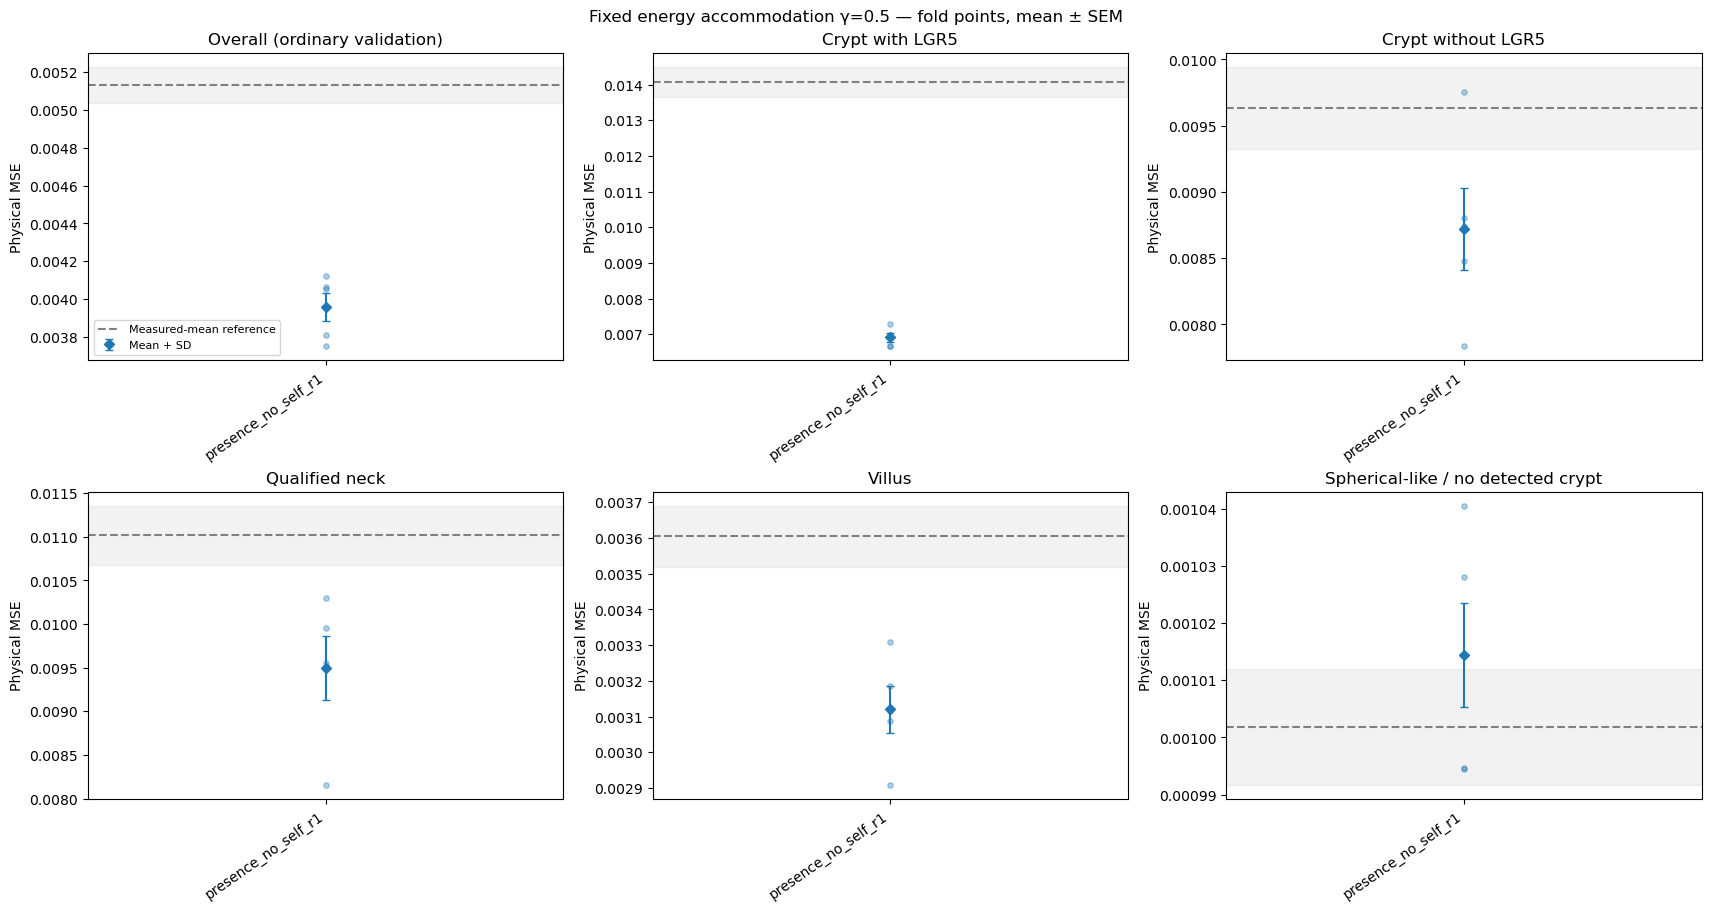

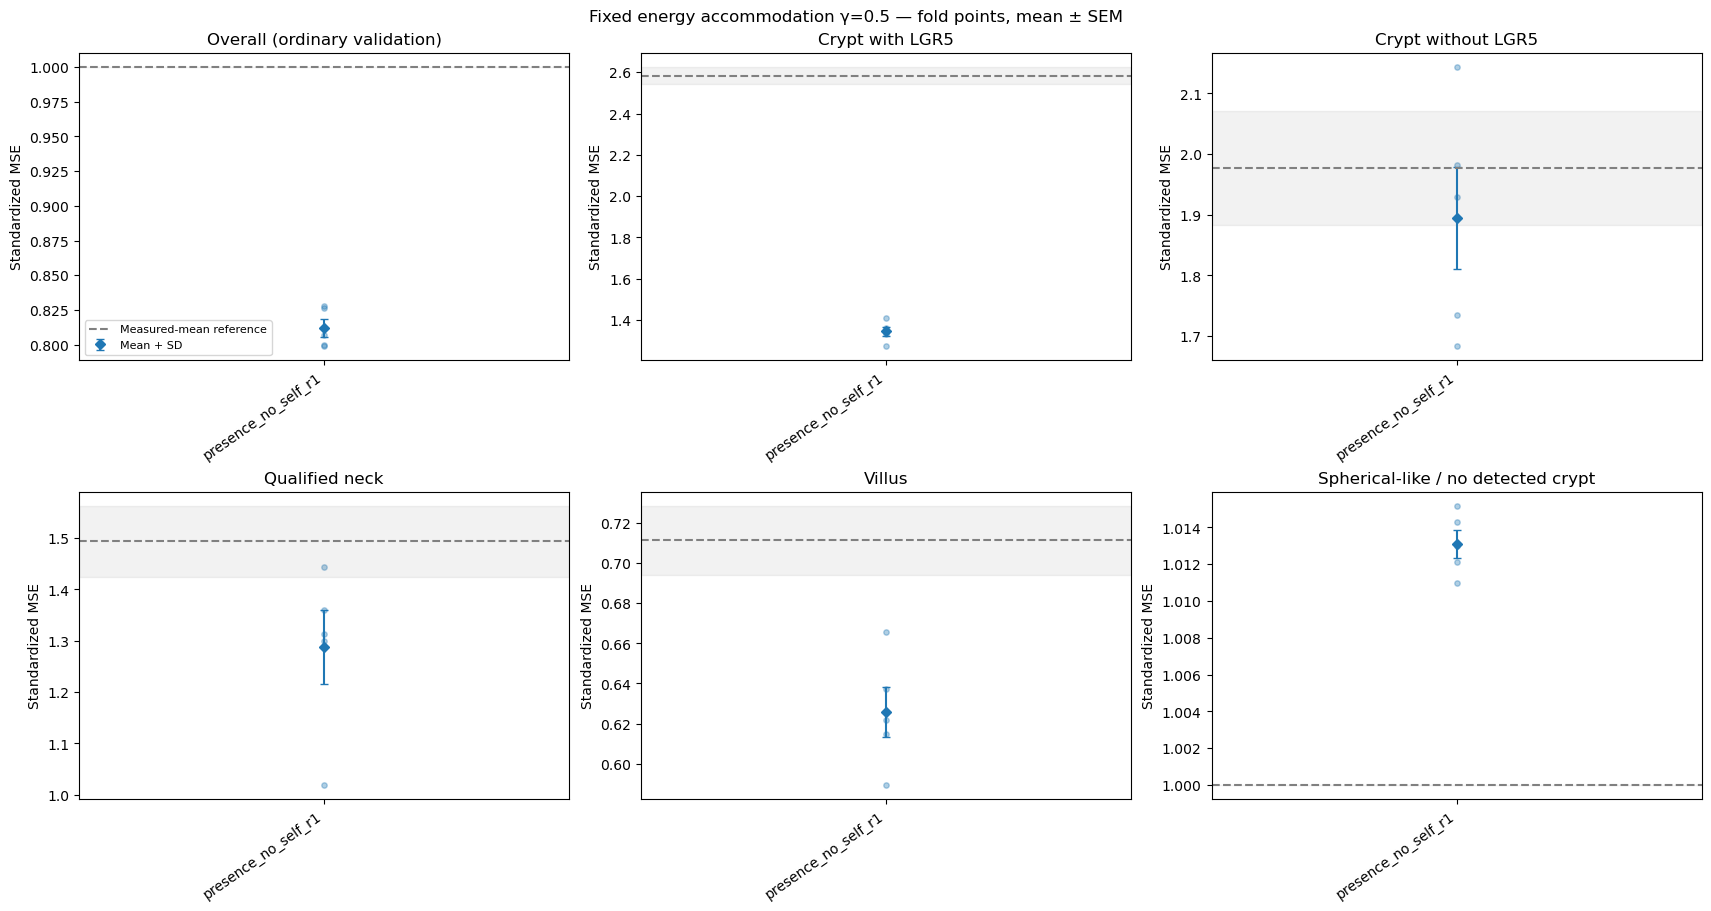

In [4]:
# Each panel uses exactly the same organoids for all selected models.
for metric in MSE_METRICS:
    variants=list(dict.fromkeys(selected.variant))
    fig,axes=plt.subplots(int(np.ceil(len(REGIONS)/3)),3,figsize=(17,4.5*int(np.ceil(len(REGIONS)/3))),squeeze=False,layout='constrained')
    for ax,region in zip(axes.flat,REGIONS):
        for mi,mode in enumerate(TARGET_MODES):
            for vi,variant in enumerate(variants):
                d=fold_scores[(fold_scores.target_mode==mode)&(fold_scores.variant==variant)&(fold_scores.region==region)]
                if d.empty:continue
                x=vi+(mi-(len(TARGET_MODES)-1)/2)*.24
                ax.scatter(np.full(len(d),x),d[metric],s=15,color=mode_colors[mode],alpha=.35)
                ax.errorbar(x,d[metric].mean(),yerr=d[metric].sem() if len(d)>1 else 0,fmt='D',ms=5,color=mode_colors[mode],capsize=3,label=mode_labels[mode] if vi==0 else None)
        baseline=fold_scores[(fold_scores.region==region)&(fold_scores.variant=='measured_mean')][metric]
        if len(baseline):
            ax.axhline(baseline.mean(),color='gray',ls='--',label='Measured-mean reference')
            if len(baseline)>1:ax.axhspan(baseline.mean()-(baseline.sem() if len(baseline)>1 else 0),baseline.mean()+(baseline.sem() if len(baseline)>1 else 0),color='gray',alpha=.1)
        ax.set_xticks(range(len(variants)),variants,rotation=35,ha='right')
        ax.set(title=region_labels.get(region,region),ylabel='Physical MSE' if metric=='mse' else 'Standardized MSE')
    for unused in list(axes.flat)[len(REGIONS):]:unused.set_visible(False)
    axes.flat[0].legend(fontsize=8)
    fig.suptitle(f'Fixed energy accommodation γ={GAMMA:g} — fold points, mean ± SEM' + ('; GIN has no γ' if (selected.family=='gin').any() else ''))
    save_figure(fig,f'01_model_comparison_{metric}')


## Validation MSE by cell identity

Evaluate the same saved predictions and measured-mean baseline separately on cells of each **exclusive identity**, including Unassigned. The baseline predicts each organoid's measured mean at every cell; it does not fit a separate mean for each identity. In standardized coordinates this baseline is zero. These are final predictions after accommodation and graph-mean centering, not errors of the center coefficients in isolation.

By default use ordinary held-out organoids, matching overall validation. Within each organoid, average squared error over the selected identity's cells, then average equally over supporting organoids in each fold, then equally over folds. Set `IDENTITY_WEIGHTING='cell'` to instead pool matching cells within each fold. The two panels show physical and SD-normalized MSE. Small points are folds, large diamonds means with fold SEM; faint lines pair baseline and model errors from the same fold. Cell and organoid counts are unique support across the selected cohort, not duplicated counts across fitted folds. Spherical results, if selected, reuse the same external organoids across folds.

The standardized baseline MSE need not equal one within an identity: normalization uses **all cells of each organoid**, whereas these panels select only that identity.


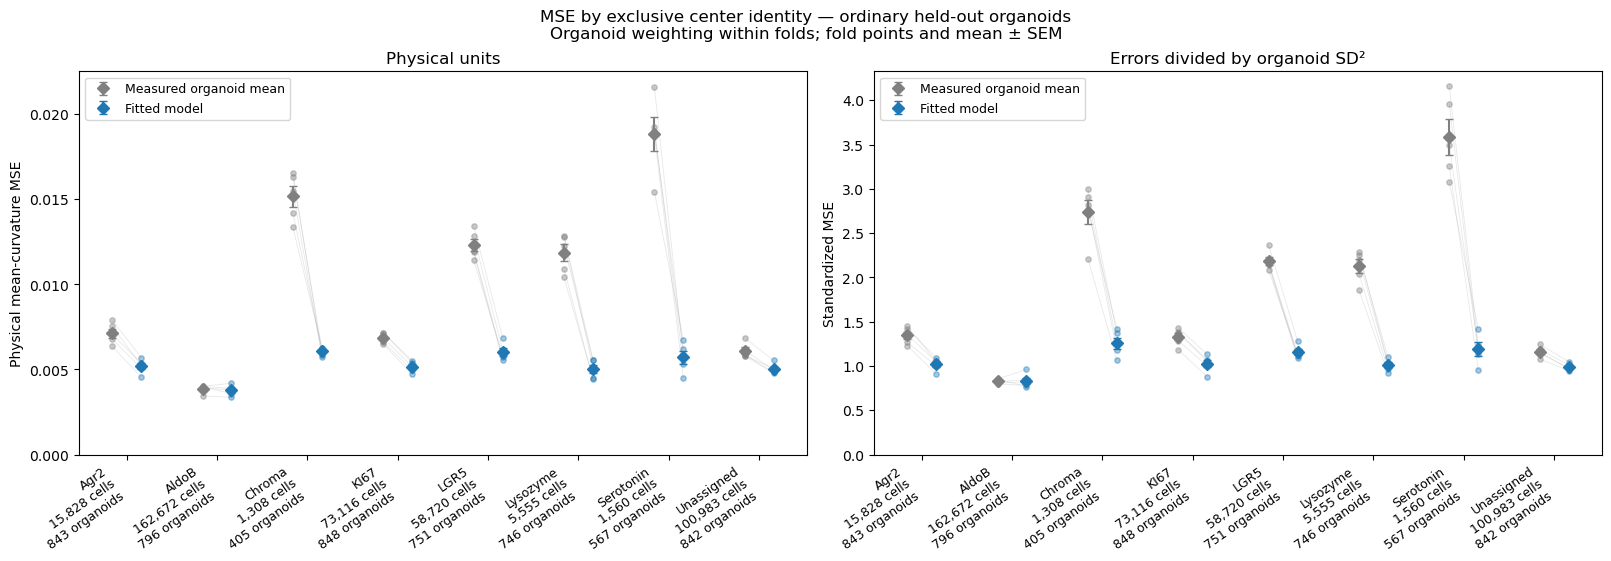

In [5]:
# Compare the model and its measured-mean reference on the same identity-selected cells.
if IDENTITY_COHORT not in ('val','spherical') or IDENTITY_WEIGHTING not in ('organoid','cell'):
    raise ValueError('Choose val/spherical and organoid/cell weighting.')
if selected.groupby('fold').size().max()!=1:
    raise ValueError('Select one model, target mode and accommodation per fold for identity inspection.')
identity_rows=[]
for rec in selected.itertuples():
    prepared=load_bundle(run/rec.input_bundle)
    graphs=prepared['physical_groups'][IDENTITY_COHORT]
    if not graphs:continue
    names=prepared['marker_names']+['Unassigned']
    if names!=identities:raise ValueError('Identity order differs across folds.')
    with np.load(run/'predictions'/f'{rec.key}_{IDENTITY_COHORT}.npz',allow_pickle=False) as archive:
        if list(archive['organoid_ids'])!=[str(g.organoid_str) for g in graphs]:raise ValueError('Organoid alignment differs.')
        for graph,start,stop in zip(graphs,archive['offsets'][:-1],archive['offsets'][1:]):
            oid=str(graph.organoid_str);moment=prepared['moments'][oid]
            truth=archive['truth'][start:stop];prediction=archive['prediction'][start:stop]
            ids=fate_identities(graph.x)
            if len(ids)!=len(truth):raise ValueError('Cell alignment differs.')
            np.testing.assert_allclose(truth,graph.y.numpy().reshape(-1),atol=1e-12,rtol=0)
            squared=(prediction-truth)**2
            baseline_squared=(moment.mean-truth)**2
            for identity in np.unique(ids):
                take=ids==identity
                identity_rows.append(dict(fold=rec.fold,key=rec.key,organoid_str=oid,identity=names[identity],
                    cohort=IDENTITY_COHORT,cells=int(take.sum()),model_mse=float(squared[take].mean()),
                    baseline_mse=float(baseline_squared[take].mean()),
                    model_standardized_mse=float(squared[take].mean()/moment.scale**2),
                    baseline_standardized_mse=float(baseline_squared[take].mean()/moment.scale**2),
                    observed_mean_z=float(((truth[take]-moment.mean)/moment.scale).mean()),
                    predicted_mean_z=float(((prediction[take]-moment.mean)/moment.scale).mean())))
identity_scores=pd.DataFrame(identity_rows)
if identity_scores.empty:raise ValueError('No cells in the selected identity evaluation cohort.')
identity_fold_rows=[]
identity_value_columns=['model_mse','baseline_mse','model_standardized_mse','baseline_standardized_mse','observed_mean_z','predicted_mean_z']
for (fold,identity),group in identity_scores.groupby(['fold','identity']):
    weights=group.cells.to_numpy() if IDENTITY_WEIGHTING=='cell' else np.ones(len(group))
    identity_fold_rows.append(dict(fold=fold,identity=identity,cells=int(group.cells.sum()),organoids=len(group),
        **{column:float(np.average(group[column],weights=weights)) for column in identity_value_columns}))
identity_fold_scores=pd.DataFrame(identity_fold_rows)
identity_summary=identity_fold_scores.groupby('identity')[identity_value_columns].agg(['mean','sem'])
identity_summary.columns=['_'.join(c) for c in identity_summary.columns]
identity_summary=identity_summary.reset_index()
identity_support=identity_scores.drop_duplicates(['organoid_str','identity']).groupby('identity').agg(
    cells=('cells','sum'),organoids=('organoid_str','nunique')).reindex(identities,fill_value=0)
for filename,frame in [('identity_organoid_scores',identity_scores),('identity_fold_scores',identity_fold_scores),
                       ('identity_summary',identity_summary),('identity_support',identity_support.reset_index())]:
    frame.to_csv(OUTPUT_DIR/f'{filename}.csv',index=False)
fig,axes=plt.subplots(1,len(MSE_METRICS),figsize=(8*len(MSE_METRICS),5.5),squeeze=False,layout='constrained')
for ax,metric in zip(axes.flat,MSE_METRICS):
    for index,identity in enumerate(identities):
        group=identity_fold_scores[identity_fold_scores.identity==identity]
        if group.empty:continue
        for row in group.itertuples():
            ax.plot([index-.16,index+.16],[getattr(row,f'baseline_{metric}'),getattr(row,f'model_{metric}')],
                color='gray',lw=.6,alpha=.18,zorder=1)
        for kind,offset,color,label in [('baseline',-.16,'gray','Measured organoid mean'),('model',.16,'tab:blue','Fitted model')]:
            values=group[f'{kind}_{metric}']
            ax.scatter(np.full(len(values),index+offset),values,s=15,alpha=.4,color=color,zorder=2)
            ax.errorbar(index+offset,values.mean(),yerr=values.sem() if len(values)>1 else 0,
                fmt='D',color=color,ms=6,capsize=3,label=label if index==0 else None,zorder=3)
    tick_labels=[f'{name}\n{int(identity_support.loc[name,"cells"]):,} cells\n{int(identity_support.loc[name,"organoids"]):,} organoids' for name in identities]
    ax.set_xticks(range(len(identities)),tick_labels,rotation=35,ha='right',fontsize=9)
    ax.set(ylabel='Physical mean-curvature MSE' if metric=='mse' else 'Standardized MSE',
           title='Physical units' if metric=='mse' else 'Errors divided by organoid SD²')
    ax.set_ylim(bottom=0);ax.legend(fontsize=9)
cohort_label='ordinary held-out organoids' if IDENTITY_COHORT=='val' else 'external spherical-like organoids'
fig.suptitle(f'MSE by exclusive center identity — {cohort_label}\n{IDENTITY_WEIGHTING.capitalize()} weighting within folds; fold points and mean ± SEM')
save_figure(fig,'01b_identity_mse')


## Center preferences and interaction amplitudes
Plot saved coefficients, retaining individual folds. A positive pair coefficient raises the unprojected local preference when its neighboring source identity is present. Center coefficients share an arbitrary common zero. Coefficient variation across folds does not establish causal signaling.

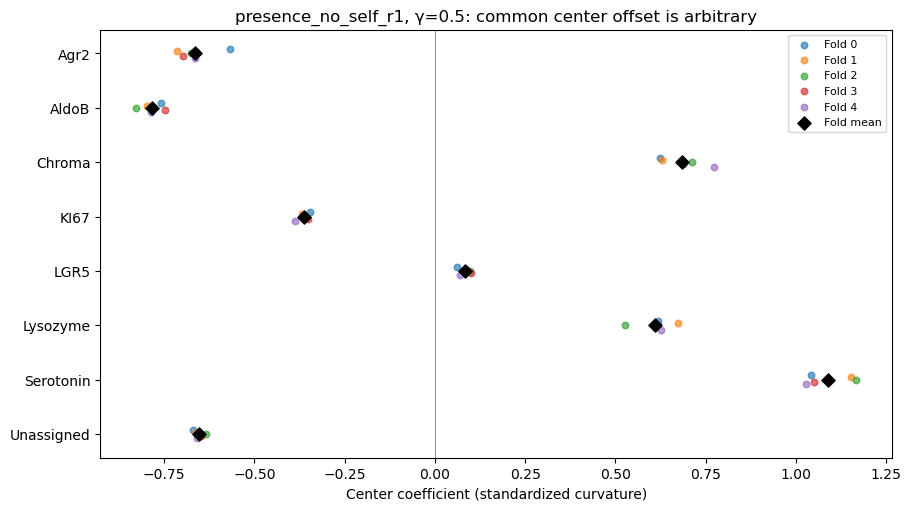

/tmp/ipykernel_139549/3054380215.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  included=panel[panel.fold==fold].set_index('source').included.reindex(identities).fillna(False)
/tmp/ipykernel_139549/3054380215.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  included=panel[panel.fold==fold].set_index('source').included.reindex(identities).fillna(False)
/tmp/ipykernel_139549/3054380215.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=

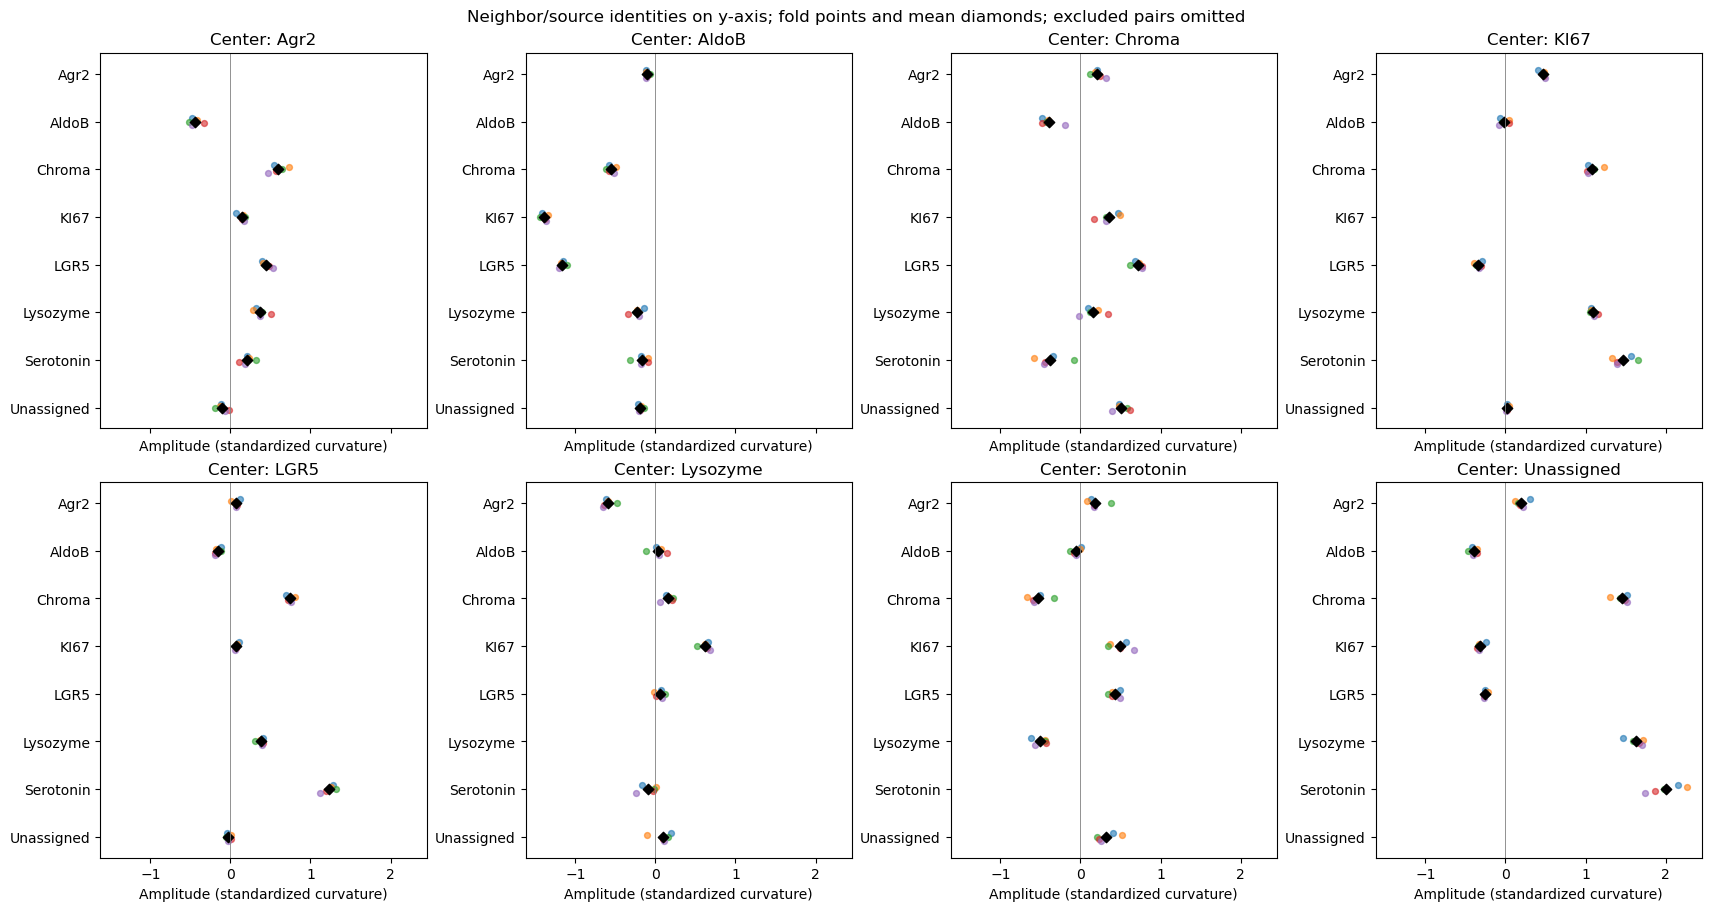

In [6]:
mode=TARGET_MODES[0];variant=VARIANTS[0]
unit='standardized curvature' if mode=='standardized' else 'physical residual curvature'
folds=sorted(selected.fold.unique());fold_colors=plt.get_cmap('tab10')
fig,ax=plt.subplots(figsize=(9,5),layout='constrained')
for fi,fold in enumerate(folds):
    values=coefficients[(coefficients.family=='center')&(coefficients.fold==fold)].set_index('recipient').value.reindex(identities)
    ax.scatter(values,np.arange(len(identities))+.04*(fi-(len(folds)-1)/2),color=fold_colors(fi),s=22,alpha=.65,label=f'Fold {fold}')
mean=coefficients[coefficients.family=='center'].groupby('recipient').value.mean().reindex(identities)
ax.scatter(mean,range(len(identities)),marker='D',color='black',label='Fold mean',s=45)
ax.axvline(0,color='gray',lw=.6);ax.set_yticks(range(len(identities)),identities);ax.invert_yaxis()
ax.set(xlabel=f'Center coefficient ({unit})',title=f'{variant}, γ={GAMMA:g}: common center offset is arbitrary');ax.legend(fontsize=8)
save_figure(fig,'02_center_coefficients')
pairs=coefficients[coefficients.family=='interaction']
if not pairs.empty:
    fig,axes=plt.subplots(2,int(np.ceil(len(identities)/2)),figsize=(17,9),sharex=True,sharey=True,layout='constrained')
    for ax,A in zip(axes.flat,identities):
        panel=pairs[pairs.recipient==A]
        for fi,fold in enumerate(folds):
            values=panel[panel.fold==fold].set_index('source').value.reindex(identities)
            included=panel[panel.fold==fold].set_index('source').included.reindex(identities).fillna(False)
            ax.scatter(values[included],np.flatnonzero(included)+.04*(fi-(len(folds)-1)/2),color=fold_colors(fi),s=18,alpha=.6)
        mean=panel[panel.included==True].groupby('source').value.mean().reindex(identities)
        ax.scatter(mean,range(len(identities)),color='black',marker='D',s=28)
        ax.axvline(0,color='gray',lw=.6);ax.set(title=f'Center: {A}',xlabel=f'Amplitude ({unit})')
        ax.set_yticks(range(len(identities)),identities);ax.tick_params(labelleft=True)
    axes.flat[0].invert_yaxis()
    fig.suptitle('Neighbor/source identities on y-axis; fold points and mean diamonds; excluded pairs omitted')
    save_figure(fig,'03_interaction_coefficients')
    stability=pairs[pairs.included==True].groupby(['recipient','source']).value.agg(['mean','std','min','max','count']).reset_index()
    stability['same_sign']=(stability['min']>0)|(stability['max']<0)
    stability.to_csv(OUTPUT_DIR/'interaction_stability.csv',index=False)


## Observed curvature profiles around each lineage

Use **all focal cells** of each exclusive identity in held-out organoids. First evaluate the fitted presence interactions in each cell's actual neighborhood, then apply accommodation on the **complete organoid graph**, and only afterward average over distance shells. No presence coefficient is multiplied by a neighboring marker fraction. A shell contains cells at exactly the indicated shortest-path distance; it is not a cumulative neighborhood. Hop 0 is the focal cell itself.

Compare three fields on the same cells and in the same fitted target units:

- **Local preference (orange dashed):** the center coefficient plus active presence terms, **minus its whole-organoid mean**, before accommodation.
- **Accommodated prediction (blue):** the final mean-centered energy prediction. The graph-wide mean is preserved by accommodation, so it uses the same zero as the local curve.
- **Measured curvature (black):** measured mean curvature minus its organoid mean, divided by the saved effective SD for `standardized` models. For `mean_only` models, all three curves are in physical mean-subtracted units.

The uncentered local preference is exported separately, but would have an arbitrary offset relative to the measured and predicted curves; it is therefore not overlaid here. This differs intentionally from the later artificial-preference figure, which compares unprojected quantities in a common coefficient convention.

At each distance, average target cells within the shell of each focal cell, then average focal cells of that identity within each organoid, then average organoids within each fold, and finally average folds equally. Thus large organoids, common identities and large shells do not automatically receive more weight. Shells around different focal cells can overlap: these are focal-cell-centered averages, not a disjoint partition of tissue. Empty shells are omitted, so support and neighborhood composition can vary with distance; per-distance organoid/focal-cell counts are exported and organoid ranges are shown in the panel titles. Fold curves and SEM describe variation among the fitted/evaluated folds, not independent sampling uncertainty for every overlapping neighborhood.

These are **typical observed-environment profiles**, not interventions or evidence that the focal identity caused the curvature. The controlled artificial-neighborhood experiments follow separately.


Distance profiles: fold 0, 174 val organoids, all focal cells.
Distance profiles: fold 1, 174 val organoids, all focal cells.
Distance profiles: fold 2, 174 val organoids, all focal cells.
Distance profiles: fold 3, 174 val organoids, all focal cells.
Distance profiles: fold 4, 173 val organoids, all focal cells.


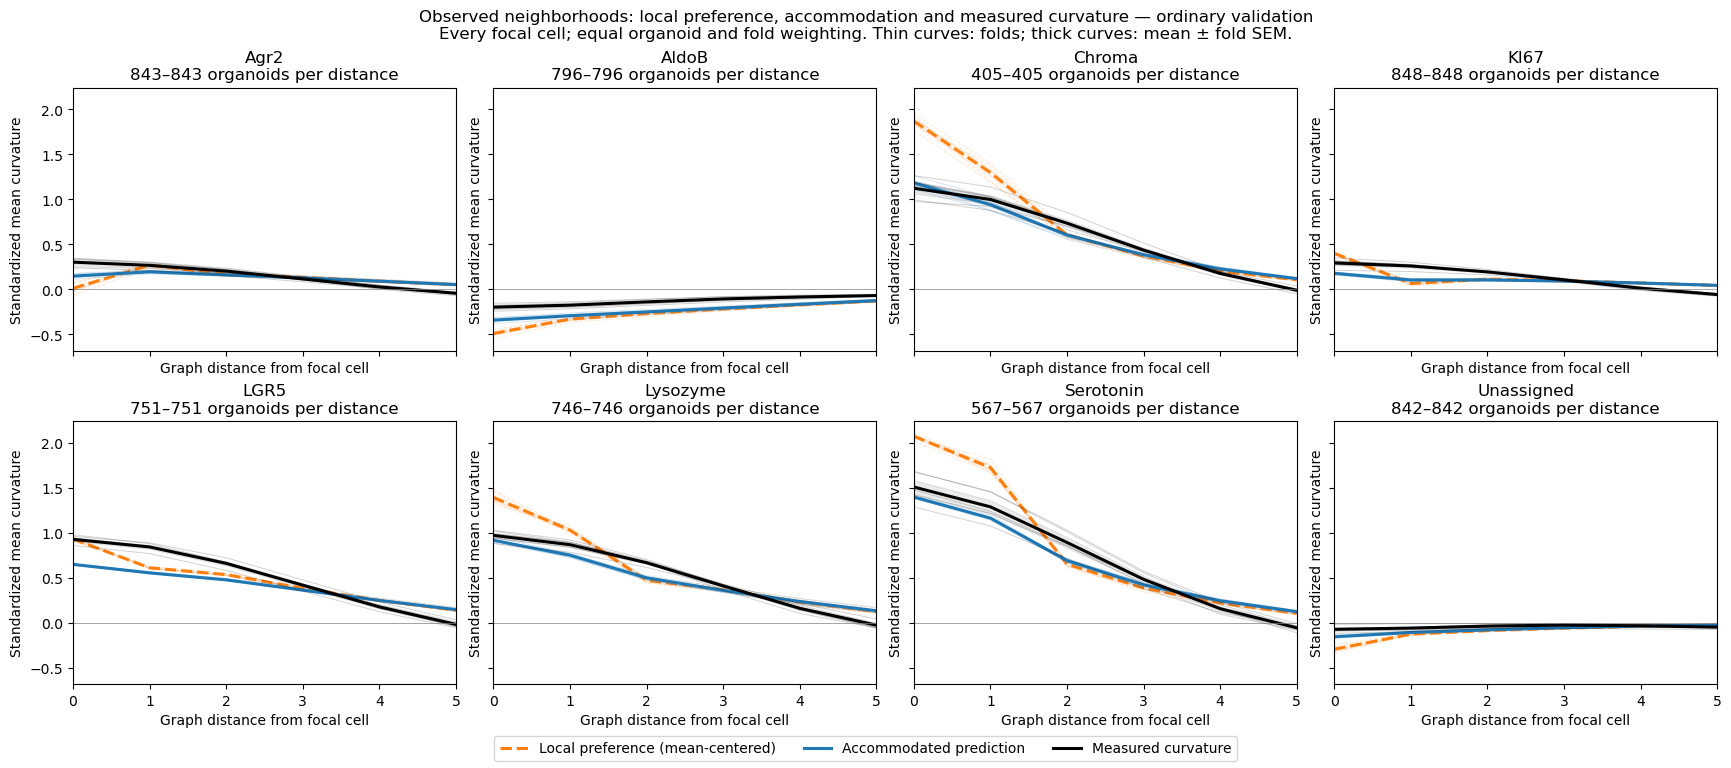

In [7]:
if PROFILE_COHORT not in ('val','spherical') or not isinstance(PROFILE_MAX_HOPS,int) or PROFILE_MAX_HOPS<0:
    raise ValueError('Choose a validation cohort and a nonnegative integer hop limit.')
if not isinstance(PROFILE_BATCH_SIZE,int) or PROFILE_BATCH_SIZE<1:
    raise ValueError('PROFILE_BATCH_SIZE must be a positive integer.')
if set(selected.family)!={'energy'} or selected.groupby('fold').size().max()!=1:
    raise ValueError('Select one energy model, normalization and accommodation per fold.')
profile_rows=[];profile_checks=[]
profile_fields=['local_preference','prediction','measured','raw_local_preference']
for rec in selected.itertuples():
    prepared=load_bundle(run/rec.input_bundle);model=load_bundle(run/rec.bundle)['model']
    if not model.zero_mean_output:raise ValueError('This comparison requires graph-mean output projection.')
    graphs=prepared['physical_groups'][PROFILE_COHORT]
    if not graphs:continue
    if prepared['marker_names']+['Unassigned']!=identities:raise ValueError('Identity order differs across folds.')
    with np.load(run/'predictions'/f'{rec.key}_{PROFILE_COHORT}.npz',allow_pickle=False) as archive:
        if list(archive['organoid_ids'])!=[str(g.organoid_str) for g in graphs]:raise ValueError('Prediction membership differs.')
        for graph,start,stop in zip(graphs,archive['offsets'][:-1],archive['offsets'][1:]):
            oid=str(graph.organoid_str);mom=prepared['moments'][oid]
            scale=mom.scale if rec.target_mode=='standardized' else 1.
            truth=graph.y.numpy().reshape(-1)
            np.testing.assert_allclose(archive['truth'][start:stop],truth,atol=1e-12,rtol=0)
            sample=graph_samples([graph],2)[0];sample.pop('y')
            ids=sample['identity'];n=len(ids)
            # Presence is evaluated on each actual neighborhood; no fraction reweighting.
            raw_local=model._design(sample)@model.array(model.weights)*float(model.target_scale)
            local=raw_local-raw_local.mean()
            predicted=(archive['prediction'][start:stop]-mom.mean)/scale
            measured=(truth-mom.mean)/scale
            restored=model.predict_sample(sample)
            error=float(np.max(np.abs(restored-predicted)))
            if error>1e-7:raise ValueError(f'Saved field differs from full-graph accommodation: {oid}')
            np.testing.assert_allclose([local.mean(),predicted.mean(),measured.mean()],0,atol=1e-7)
            fields=np.column_stack([local,predicted,measured,raw_local])
            # Use the same undirected, deduplicated adjacency as the accommodation model.
            adjacency=sample['transition'].copy().tocsr()
            adjacency.setdiag(0);adjacency.eliminate_zeros();adjacency.data[:]=1.
            sums=np.zeros((len(identities),PROFILE_MAX_HOPS+1,len(profile_fields)))
            focal_counts=np.zeros((len(identities),PROFILE_MAX_HOPS+1),dtype=int)
            pair_counts=np.zeros_like(focal_counts)
            for first in range(0,n,PROFILE_BATCH_SIZE):
                roots=np.arange(first,min(first+PROFILE_BATCH_SIZE,n))
                distances=dijkstra(adjacency,directed=False,indices=roots,unweighted=True,limit=PROFILE_MAX_HOPS)
                for hop in range(PROFILE_MAX_HOPS+1):
                    shell=distances==hop;population=shell.sum(axis=1)
                    usable=population>0
                    shell_means=np.divide(shell@fields,population[:,None],out=np.zeros((len(roots),len(profile_fields))),where=usable[:,None])
                    for identity in np.unique(ids[roots]):
                        take=usable&(ids[roots]==identity)
                        sums[identity,hop]+=shell_means[take].sum(axis=0)
                        focal_counts[identity,hop]+=int(take.sum())
                        pair_counts[identity,hop]+=int(population[take].sum())
            for identity in np.unique(ids):
                np.testing.assert_allclose(sums[identity,0]/focal_counts[identity,0],fields[ids==identity].mean(axis=0),atol=1e-10)
                for hop in range(PROFILE_MAX_HOPS+1):
                    count=focal_counts[identity,hop]
                    if not count:continue  # Empty shells contribute no invented zero.
                    means=sums[identity,hop]/count
                    profile_rows.append(dict(fold=rec.fold,key=rec.key,cohort=PROFILE_COHORT,organoid_str=oid,identity=identities[identity],
                        hop=hop,focal_cells=int(count),center_target_pairs=int(pair_counts[identity,hop]),
                        **dict(zip(profile_fields,map(float,means)))))
            profile_checks.append(dict(fold=rec.fold,organoid_str=oid,max_prediction_difference=error))
    print(f'Distance profiles: fold {rec.fold}, {len(graphs)} {PROFILE_COHORT} organoids, all focal cells.')
lineage_profiles=pd.DataFrame(profile_rows)
if lineage_profiles.empty:raise ValueError('No organoids available for distance profiles.')
profile_fold_scores=lineage_profiles.groupby(['fold','identity','hop'])[profile_fields].mean().reset_index()
profile_summary=profile_fold_scores.groupby(['identity','hop'])[profile_fields].agg(['mean','sem'])
profile_summary.columns=['_'.join(column) for column in profile_summary.columns]
profile_summary=profile_summary.reset_index()
profile_support=lineage_profiles.drop_duplicates(['organoid_str','identity','hop']).groupby(['identity','hop']).agg(
    organoids=('organoid_str','nunique'),focal_cells=('focal_cells','sum'),center_target_pairs=('center_target_pairs','sum')).reset_index()
for filename,frame in [('lineage_distance_organoid_profiles',lineage_profiles),('lineage_distance_fold_profiles',profile_fold_scores),
                       ('lineage_distance_summary',profile_summary),('lineage_distance_support',profile_support),
                       ('lineage_distance_verification',pd.DataFrame(profile_checks))]:
    frame.to_csv(OUTPUT_DIR/f'{filename}.csv',index=False)
# Each shell is averaged within focal cell, then focal identity/organoid, then fold.
profile_styles=[('local_preference','Local preference (mean-centered)','tab:orange','--'),
                ('prediction','Accommodated prediction','tab:blue','-'),
                ('measured','Measured curvature','black','-')]
columns=min(4,len(identities));rows=int(np.ceil(len(identities)/columns))
fig,axes=plt.subplots(rows,columns,figsize=(4.3*columns,3.8*rows),squeeze=False,sharex=True,sharey=True,layout='constrained')
profile_unit='Standardized mean curvature' if TARGET_MODES[0]=='standardized' else 'Mean-subtracted curvature (physical units)'
for ax,identity in zip(axes.flat,identities):
    panel=profile_fold_scores[profile_fold_scores.identity==identity]
    for field,label,color,linestyle in profile_styles:
        for _,fold in panel.groupby('fold'):
            ax.plot(fold.hop,fold[field],color=color,ls=linestyle,lw=.7,alpha=.18)
        curve=panel.groupby('hop')[field].agg(['mean','sem']);x=curve.index.to_numpy()
        ax.plot(x,curve['mean'],color=color,ls=linestyle,lw=2.2,label=label)
        ax.fill_between(x,curve['mean']-curve['sem'].fillna(0),curve['mean']+curve['sem'].fillna(0),color=color,alpha=.08)
    support=profile_support[profile_support.identity==identity]
    ax.axhline(0,color='gray',lw=.5)
    ax.set(title=f'{identity}\n{int(support.organoids.min())}–{int(support.organoids.max())} organoids per distance',
           xlabel='Graph distance from focal cell',ylabel=profile_unit)
    ax.set_xticks(range(PROFILE_MAX_HOPS+1));ax.set_xlim(0,PROFILE_MAX_HOPS if PROFILE_MAX_HOPS else .5)
for ax in list(axes.flat)[len(identities):]:ax.set_visible(False)
handles,labels=axes.flat[0].get_legend_handles_labels()
fig.legend(handles,labels,loc='outside lower center',ncol=3,fontsize=10)
profile_cohort_label='ordinary validation' if PROFILE_COHORT=='val' else 'external spherical-like validation'
fig.suptitle(f'Observed neighborhoods: local preference, accommodation and measured curvature — {profile_cohort_label}\n'
             'Every focal cell; equal organoid and fold weighting. Thin curves: folds; thick curves: mean ± fold SEM.')
save_figure(fig,'03b_observed_lineage_distance_profiles')


## Artificial neighborhoods: insertion and uniform control

Construct a periodic triangular lattice: every cell has **six neighbors**, including across its boundary. It is a diagnostic adjacency, not a spherical surface or a physical geometry simulation. Replace one KI67/LGR5/Unassigned background cell with Agr2/Serotonin/Lysozyme/Chroma; the control exchanges it back to the background identity. No observed curvature, mean or SD is invented for these graphs; output remains in the fitted target units.

Compare the local preference `u`, the accommodated field before mean centering, and the actual mean-centered prediction. A uniform graph has exactly zero final prediction. The unprojected figure compares the embedded cell's center coefficient with its total local preference and accommodated field using the same saved coefficient convention. That coefficient alone omits interactions with the surrounding background.

Because accommodation is linear at fixed gamma, decompose the insertion response exactly into (i) changed center preference, (ii) changed pair contributions, and (iii) the uniform output-centering shift. Pair changes include changes at the embedded cell as well as its neighbors. The scalar shift is not long-range mechanical propagation. A larger torus checks the local unprojected field for finite-size effects; projected fields retain their expected size-dependent uniform offset.

In [8]:
if len(TARGET_MODES)!=1 or len(VARIANTS)!=1 or set(selected.family)!={'energy'}:
    raise ValueError('Artificial neighborhoods require one selected energy variant and normalization.')
if LATTICE_SIDE<2*MAX_DISTANCE+5 or CHECK_LATTICE_SIDE<=LATTICE_SIDE:
    raise ValueError('Use a large torus and a larger independent size check.')
artificial_rows=[];center_rows=[];size_checks=[]
for rec in selected.itertuples():
    model=load_bundle(run/rec.bundle)['model'];co=model.coefficients([1])
    for side in [LATTICE_SIDE,CHECK_LATTICE_SIDE]:
        edges=triangular_lattice_edges(side);n=side*side;origin=(side//2)*side+side//2
        degree=torch.bincount(edges[0],minlength=n).numpy()
        if not np.all(degree==6):raise ValueError('Every synthetic cell must have six neighbors.')
        adjacency=csr_matrix((np.ones(edges.shape[1]),edges.numpy()),shape=(n,n))
        distance=shortest_path(adjacency,directed=False,unweighted=True,indices=origin).astype(int)
        lap=diags(degree)-adjacency
        solve=factorized((eye(n,format='csc')+float(GAMMA)*lap).tocsc())
        def make_sample(background,source):
            ids=np.full(n,identities.index(background),int);ids[origin]=identities.index(source)
            x=np.eye(len(identities),dtype=np.float32)[ids,:-1]
            graph=Data(x=torch.tensor(x),edge_index=edges,y=torch.zeros(n),organoid_str=f'synthetic_{side}_{background}_{source}')
            sample=graph_samples([graph],2)[0];sample.pop('y')
            return sample
        def fields(sample):
            # Recover unprojected preference without altering the fitted model.
            local=model._design(sample)@model.array(model.weights)*float(model.target_scale)
            raw=solve(local)
            projected=raw-raw.mean()
            actual=model.predict_sample(sample)
            np.testing.assert_allclose(projected,actual,atol=1e-9,rtol=1e-9)
            return local,raw,projected
        for background in BACKGROUND_IDENTITIES:
            base=make_sample(background,background);u0,h0,z0=fields(base)
            np.testing.assert_allclose(z0,0,atol=1e-10)
            for source in EMBEDDED_IDENTITIES:
                sample=make_sample(background,source);local,raw,projected=fields(sample)
                a_source=float(co['center'][0,identities.index(source)])
                a_background=float(co['center'][0,identities.index(background)])
                identity_delta=np.zeros(n);identity_delta[origin]=a_source-a_background
                # Includes both newly present sources and disappearance of old background signals at the changed center.
                pair_delta=local-u0-identity_delta
                identity_field=solve(identity_delta);pair_field=solve(pair_delta)
                delta=projected-z0
                uniform_shift=float((raw-h0).mean())
                np.testing.assert_allclose(delta,identity_field+pair_field-uniform_shift,atol=1e-9)
                for hop in range(MAX_DISTANCE+1):
                    take=distance==hop
                    artificial_rows.append(dict(fold=rec.fold,side=side,background=background,source=source,hop=hop,cells=int(take.sum()),
                        local=float(local[take].mean()),raw=float(raw[take].mean()),prediction=float(projected[take].mean()),
                        uniform_raw=float(h0[take].mean()),uniform_prediction=float(z0[take].mean()),a_source=a_source,
                        delta=float(delta[take].mean()),identity_component=float(identity_field[take].mean()),
                        interaction_component=float(pair_field[take].mean()),projection_component=-uniform_shift,
                        raw_delta=float((raw-h0)[take].mean()),direction_sd=float(delta[take].std())))
                if side==LATTICE_SIDE:
                    center_rows.append(dict(fold=rec.fold,background=background,source=source,a_source=a_source,a_background=a_background,
                        uniform_local=float(u0[origin]),inserted_local=float(local[origin]),raw_prediction=float(raw[origin]),
                        centered_prediction=float(projected[origin]),projected_response=float(delta[origin]),projection_shift=-uniform_shift))
artificial=pd.DataFrame(artificial_rows);centers=pd.DataFrame(center_rows)
for (fold,background,source),d in artificial.groupby(['fold','background','source']):
    small=d[d.side==LATTICE_SIDE].set_index('hop');large=d[d.side==CHECK_LATTICE_SIDE].set_index('hop')
    size_checks.append(dict(fold=fold,background=background,source=source,
        max_raw_response_difference=float(np.max(abs(small.raw_delta-large.raw_delta))),
        max_projected_response_difference=float(np.max(abs(small.delta-large.delta))),
        raw_response_scale=float(np.max(abs(large.raw_delta)))))
size_checks=pd.DataFrame(size_checks)
if np.any(size_checks.max_raw_response_difference>1e-5*(1+size_checks.raw_response_scale)):
    raise ValueError('Synthetic field is sensitive to lattice size; increase both lattice sides.')
artificial.to_csv(OUTPUT_DIR/'artificial_radial_fields.csv',index=False)
centers.to_csv(OUTPUT_DIR/'artificial_center_comparison.csv',index=False)
size_checks.to_csv(OUTPUT_DIR/'artificial_size_checks.csv',index=False)
print('Synthetic checks: six neighbors everywhere; uniform graph projects to zero; independent solve and decomposition agree.')
print('Largest pre-projection finite-size difference:',size_checks.max_raw_response_difference.max())


/home/fmoller/miniforge3/envs/organoid-gnn/lib/python3.11/site-packages/scipy/sparse/_construct.py:543: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
Note: In Python 3.11, this warning can be generated by a call of scipy.sparse.diags(), but the code indicated in the warning message will refer to an internal call of scipy.sparse.diags_array(). If that happens, check your code for the use of diags().
  A = diags_array(diagonals, offsets=offsets, shape=shape, dtype=dtype)


Synthetic checks: six neighbors everywhere; uniform graph projects to zero; independent solve and decomposition agree.
Largest pre-projection finite-size difference: 6.661338147750939e-16


## Radial fields and response decomposition
Average predictions over shortest-path distance shells. Show folds as thin translucent curves and their mean as a thick curve for each source/background combination. The three figures show actual predictions, comparison with center coefficients before centering, and the additive decomposition.

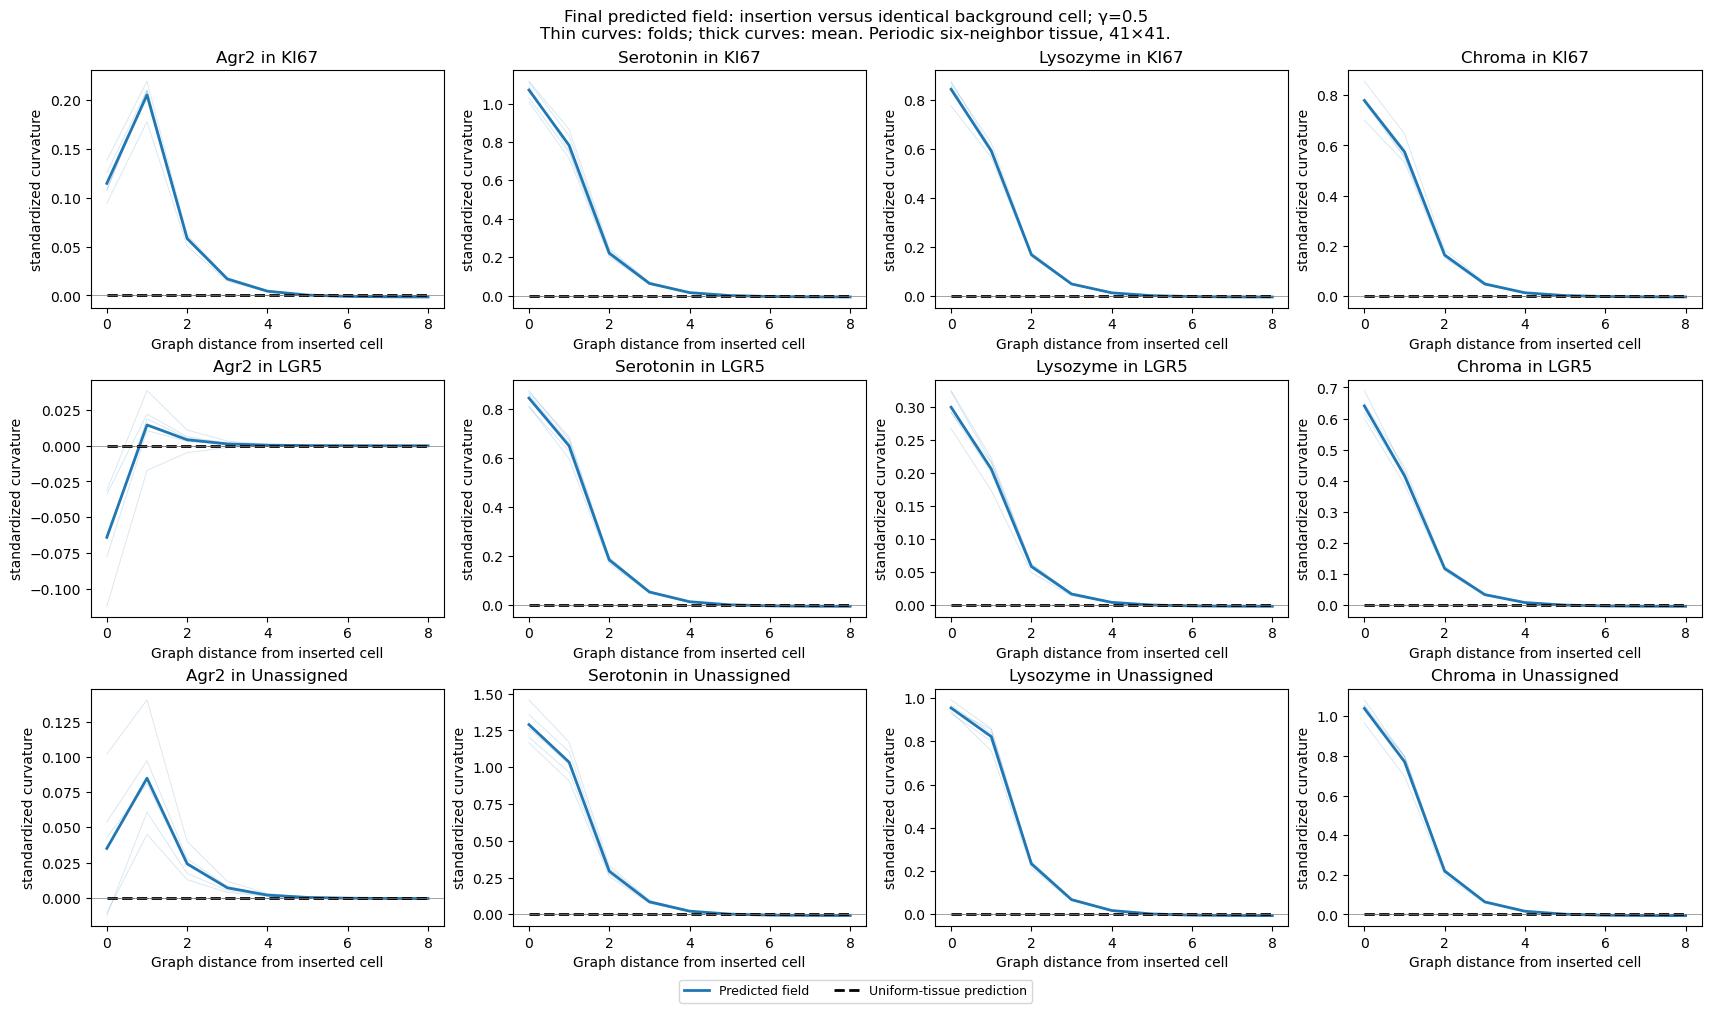

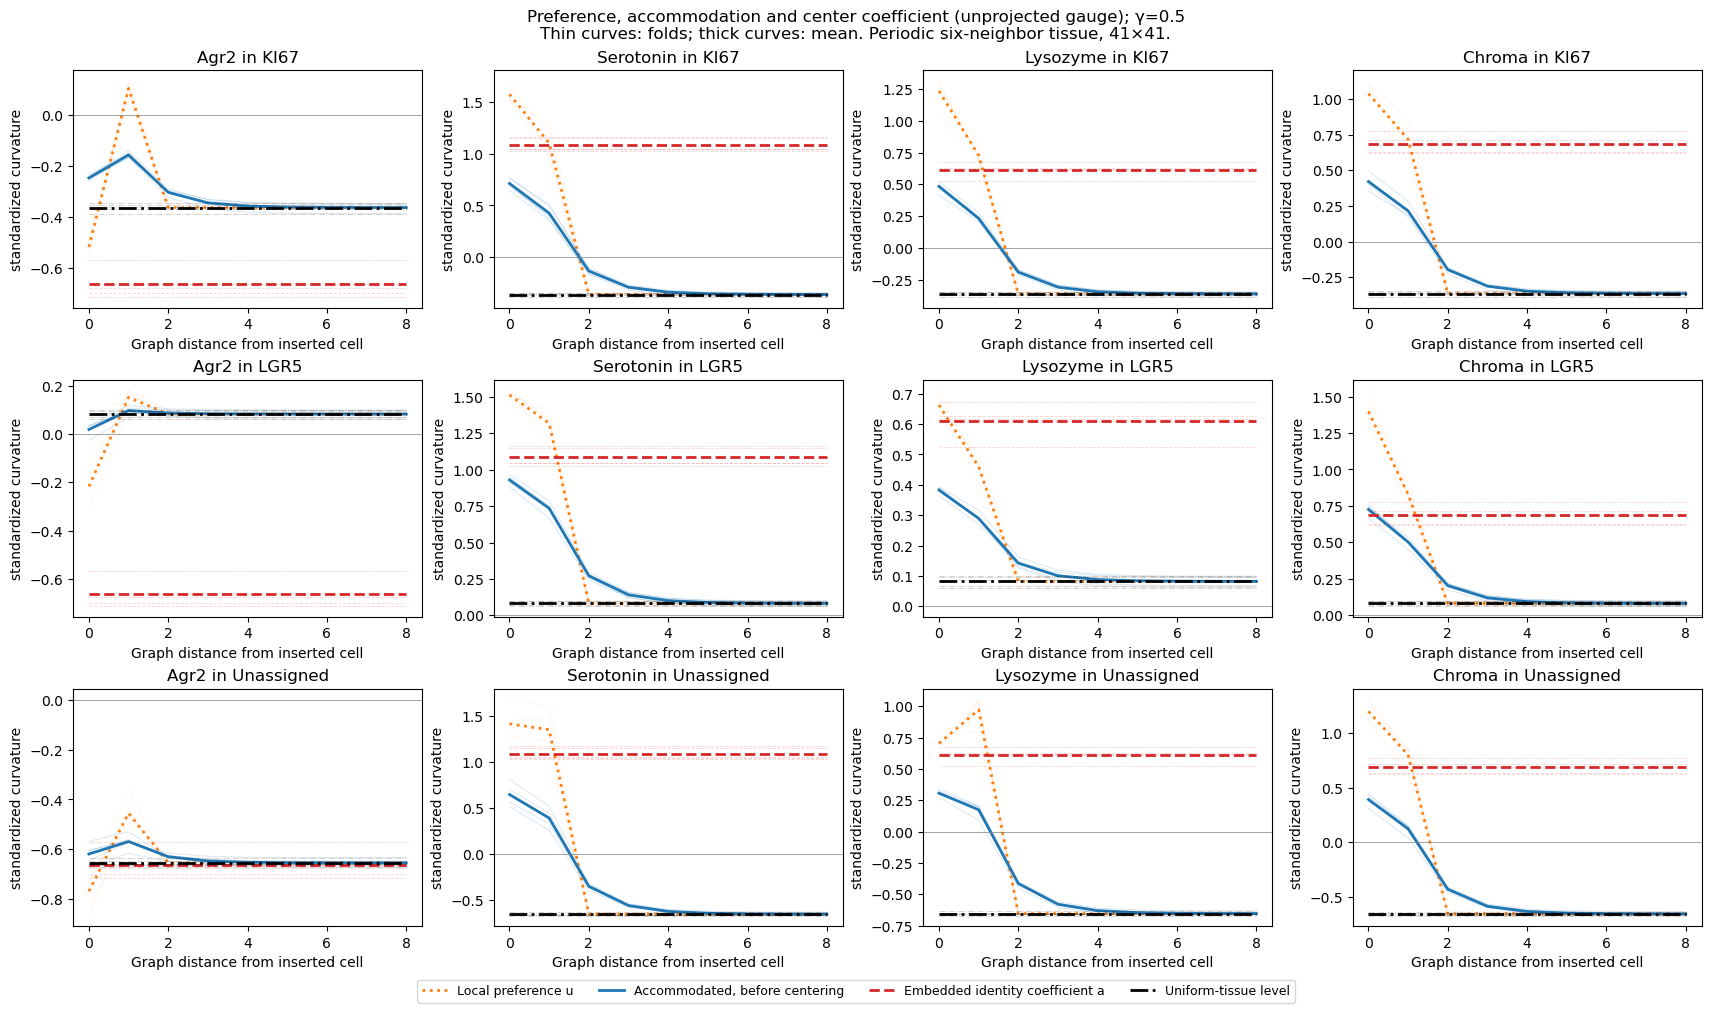

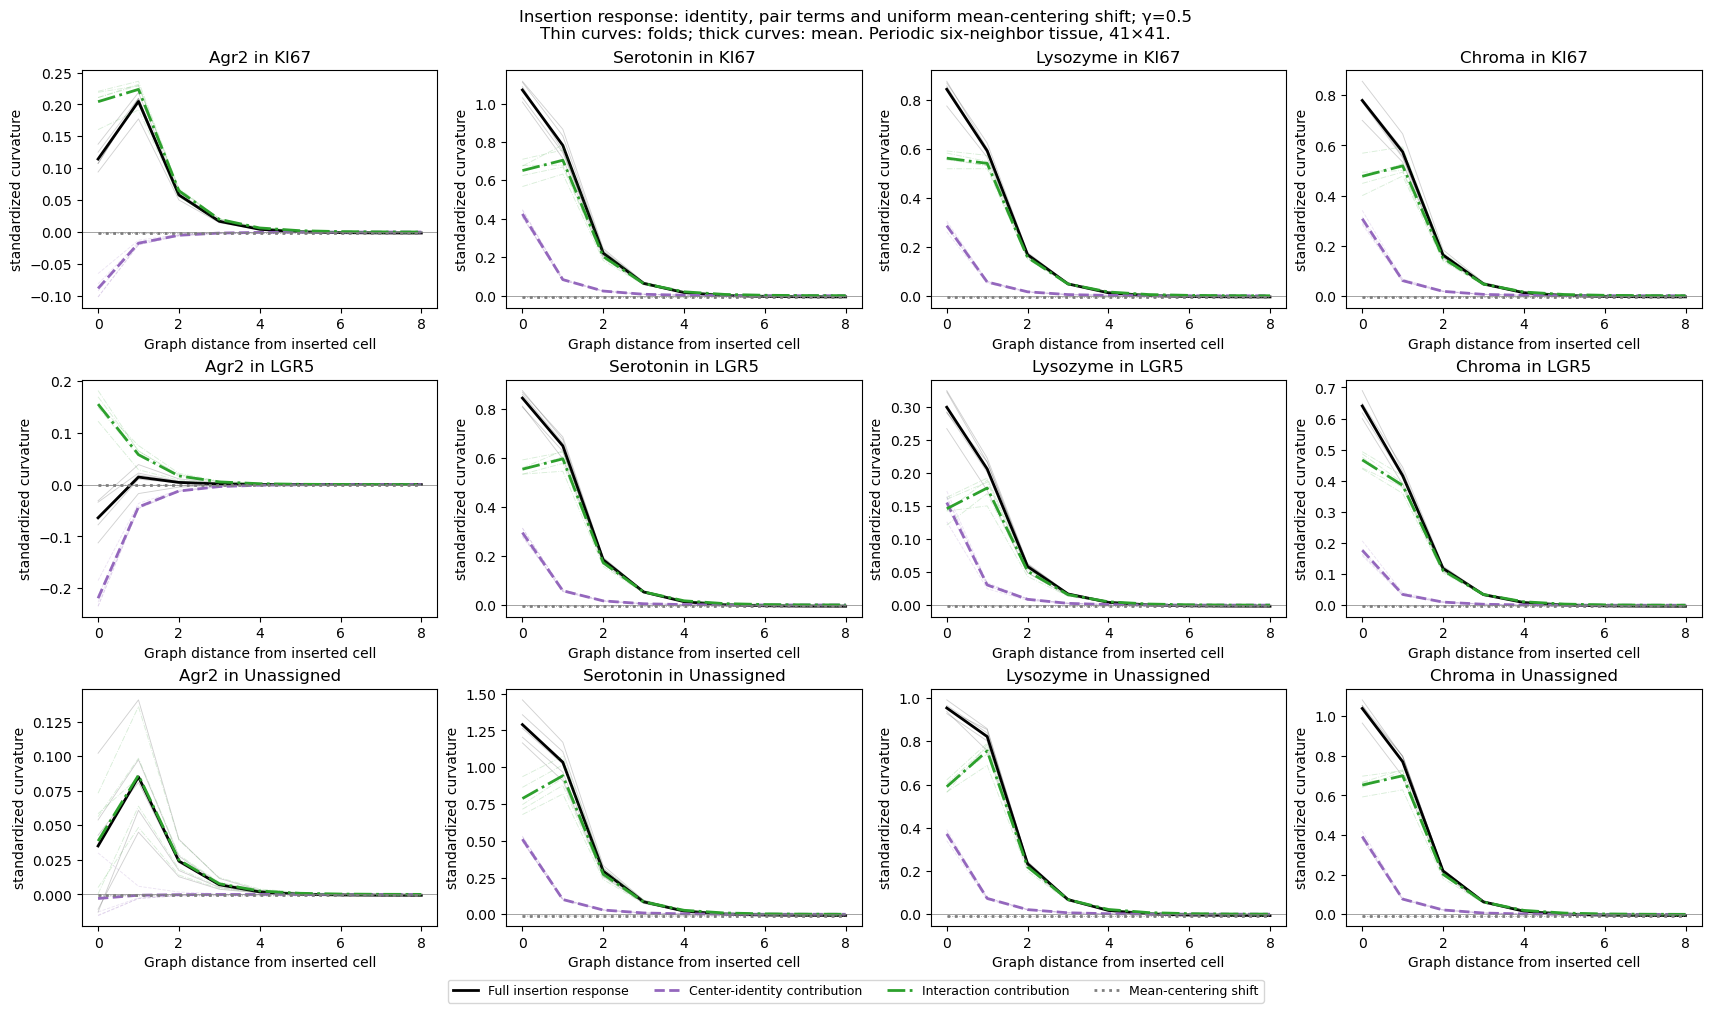

In [9]:
d=artificial[artificial.side==LATTICE_SIDE]
# All synthetic plots use the fitted target units; no measured mean or SD is invented.
styles={
    'prediction':('Predicted field','tab:blue','-'),
    'uniform_prediction':('Uniform-tissue prediction','black','--'),
    'local':('Local preference u','tab:orange',':'),
    'raw':('Accommodated, before centering','tab:blue','-'),
    'a_source':('Embedded identity coefficient a','tab:red','--'),
    'uniform_raw':('Uniform-tissue level','black','-.'),
    'delta':('Full insertion response','black','-'),
    'identity_component':('Center-identity contribution','tab:purple','--'),
    'interaction_component':('Interaction contribution','tab:green','-.'),
    'projection_component':('Mean-centering shift','tab:gray',':'),
}
figures=[('04_artificial_predictions',['prediction','uniform_prediction'],'Final predicted field: insertion versus identical background cell'),
         ('05_artificial_preference',['local','raw','a_source','uniform_raw'],'Preference, accommodation and center coefficient (unprojected gauge)'),
         ('06_artificial_decomposition',['delta','identity_component','interaction_component','projection_component'],'Insertion response: identity, pair terms and uniform mean-centering shift')]
for filename,fields,title in figures:
    fig,axes=plt.subplots(len(BACKGROUND_IDENTITIES),len(EMBEDDED_IDENTITIES),figsize=(17,10),squeeze=False,layout='constrained')
    for ai,background in enumerate(BACKGROUND_IDENTITIES):
        for bi,source in enumerate(EMBEDDED_IDENTITIES):
            ax=axes[ai,bi];panel=d[(d.background==background)&(d.source==source)]
            for field in fields:
                label,color,ls=styles[field]
                for _,f in panel.groupby('fold'):ax.plot(f.hop,f[field],color=color,ls=ls,lw=.65,alpha=.18)
                mean=panel.groupby('hop')[field].mean();ax.plot(mean.index,mean.values,label=label,color=color,ls=ls,lw=2)
            ax.axhline(0,color='gray',lw=.5);ax.set(title=f'{source} in {background}',xlabel='Graph distance from inserted cell',ylabel=unit)
            ax.set_xticks(range(0,MAX_DISTANCE+1,2))
    handles,labels=axes[0,0].get_legend_handles_labels();fig.legend(handles,labels,loc='outside lower center',ncol=len(fields),fontsize=9)
    fig.suptitle(f'{title}; γ={GAMMA:g}\nThin curves: folds; thick curves: mean. Periodic six-neighbor tissue, {LATTICE_SIDE}×{LATTICE_SIDE}.')
    save_figure(fig,filename)


## Saved outputs
Figures and machine-readable metrics are written beside the models. This notebook is the analysis record; no long automatically generated report is appended.

In [10]:
(OUTPUT_DIR/'complete.json').write_text(json.dumps(dict(models=len(selected),figures=sorted(p.name for p in OUTPUT_DIR.glob('*.png'))),indent=2))
print('Analysis saved:',OUTPUT_DIR)


Analysis saved: /home/fmoller/Projects/LearningOrganoids/GraphNN/training_results/shape_conditioned_energy_training/no_self_secretory_gamma05_20261005_144506/analysis/single_model_presence_no_self_r1_g0.5
